In [1]:
# Cell 1 - Imports
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from google.cloud import bigquery
from network_idx.config import GCS_PROJECT_ID, BQ_DATASET_ANALYTICS, BQ_FEATURES_CORRELATIONS_TRACT

In [2]:
# Load features table from BQ - the geometry as a dataframe
table_id = f"{GCS_PROJECT_ID}.{BQ_DATASET_ANALYTICS}.{BQ_FEATURES_CORRELATIONS_TRACT}"
client = bigquery.Client(project=GCS_PROJECT_ID)
# Exclude geometry
query = f"""
    SELECT *
    FROM `{table_id}`
"""
tract_df = client.query(query).to_arrow().to_pandas()
tract_df.info()

/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


<class 'pandas.DataFrame'>
RangeIndex: 83313 entries, 0 to 83312
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   tract_geoid                         83313 non-null  str    
 1   pop_ch_avg                          83313 non-null  float64
 2   pop_pctch_avg                       83313 non-null  float64
 3   estimated_census_housing_units      83313 non-null  int64  
 4   estimated_fcc_units                 83313 non-null  int64  
 5   pre_early_dev_parcels               83216 non-null  float64
 6   builder_developer_count             83216 non-null  float64
 7   landuse_change_count                83216 non-null  float64
 8   building_permit_count               83216 non-null  float64
 9   median_dist_nearest_hotspot         63190 non-null  float64
 10  median_dist_nearest_fiber_m         81944 non-null  float64
 11  pre_early_dev_parcels_bin           83313 non-null  

In [3]:
# Examine NA values and treat variables with high NA as needed
na_percentages = tract_df.isna().mean() * 100
print(na_percentages[na_percentages > 0].sort_values(ascending=False))

median_dist_nearest_hotspot    24.153493
median_dist_nearest_fiber_m     1.643201
pre_early_dev_parcels           0.116428
builder_developer_count         0.116428
building_permit_count           0.116428
landuse_change_count            0.116428
cable_penetration               0.090022
fiber_opportunity_gap           0.090022
dtype: float64


In [4]:
# Fill low-NA columns with domain-appropriate values
tract_df['pre_early_dev_parcels'] = tract_df['pre_early_dev_parcels'].fillna(0)
tract_df['builder_developer_count'] = tract_df['builder_developer_count'].fillna(0)
tract_df['building_permit_count'] = tract_df['building_permit_count'].fillna(0)
tract_df['landuse_change_count'] = tract_df['landuse_change_count'].fillna(0)
tract_df['cable_penetration'] = tract_df['cable_penetration'].fillna(0)
tract_df['fiber_opportunity_gap'] = tract_df['fiber_opportunity_gap'].fillna(1.0)

# Fill fiber distance with capped value (99th percentile)
fiber_dist_cap = tract_df['median_dist_nearest_fiber_m'].quantile(0.99)
tract_df['median_dist_nearest_fiber_m'] = tract_df['median_dist_nearest_fiber_m'].fillna(fiber_dist_cap)
print(f"Fiber distance cap (P99): {fiber_dist_cap:.0f}m")

# Examine NA values and treat variables with high NA as needed
na_percentages = tract_df.isna().mean() * 100
print(na_percentages[na_percentages > 0].sort_values(ascending=False))

Fiber distance cap (P99): 19966m
median_dist_nearest_hotspot    24.153493
dtype: float64


       median_dist_nearest_hotspot  median_dist_nearest_fiber_m
count                      63190.0                      83313.0
mean                        7446.4                       2157.8
std                         6786.9                       4278.7
min                            0.0                          0.0
25%                         1957.6                        220.4
50%                         5249.5                        521.6
75%                        11473.8                       1651.4
max                        24135.2                      24136.5
median_dist_nearest_hotspot: 20123 NAs (24.15%)
median_dist_nearest_fiber_m: 0 NAs (0.00%)
  median_dist_nearest_hotspot P50: 5249.5
  median_dist_nearest_hotspot P75: 11473.8
  median_dist_nearest_hotspot P90: 18951.6
  median_dist_nearest_hotspot P95: 21908.1
  median_dist_nearest_hotspot P99: 23779.5

  median_dist_nearest_fiber_m P50: 521.6
  median_dist_nearest_fiber_m P75: 1651.4
  median_dist_nearest_fiber_m P90: 

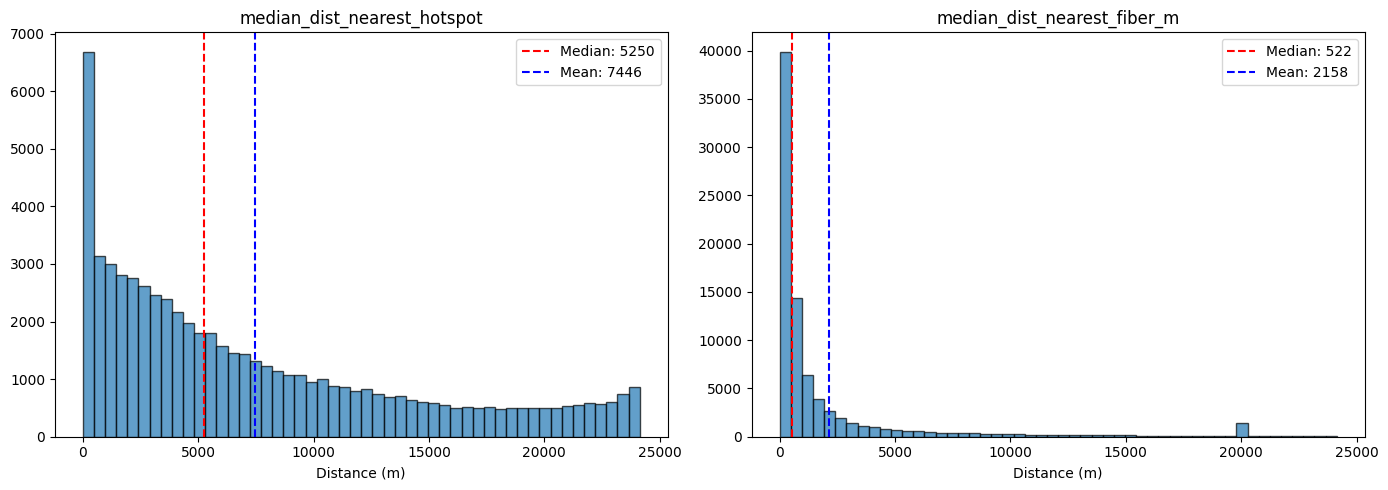

In [5]:
# Examine distribution of distance features
dist_cols = ['median_dist_nearest_hotspot', 'median_dist_nearest_fiber_m']

# Summary stats
print(tract_df[dist_cols].describe().round(1).to_string())
print("="*80)

# NA counts
for col in dist_cols:
    na_count = tract_df[col].isna().sum()
    print(f"{col}: {na_count} NAs ({na_count/len(tract_df)*100:.2f}%)")

print("="*80)

# Percentiles for non-NA values
for col in dist_cols:
    for p in [0.50, 0.75, 0.90, 0.95, 0.99]:
        print(f"  {col} P{int(p*100):02d}: {tract_df[col].quantile(p):.1f}")
    print()

# Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, dist_cols):
    data = tract_df[col].dropna()
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.0f}')
    ax.axvline(data.mean(), color='blue', linestyle='--', label=f'Mean: {data.mean():.0f}')
    ax.set_title(col)
    ax.set_xlabel('Distance (m)')
    ax.legend()
plt.tight_layout()

In [8]:
# Examine tracts where distance to growth hotspot is NA
# To check if these are mostly rural areas or are heterogeneous
hotspot_na = tract_df[tract_df['median_dist_nearest_hotspot'].isna()]
print(f"Tracts with NA distance to hotspot: {len(hotspot_na)}")

# Examine distribution of pop and housing metrics
print("Population stats:")
print(hotspot_na['pop_ch_avg'].describe().round(2).to_string())
print("="*80)
print("Housing unit stats:")
print(hotspot_na['estimated_census_housing_units'].describe().round(2).to_string())
print("="*80)
print("Provider competitive landscape:")
print(hotspot_na['provider_competitive_landscape'].value_counts(dropna=False).to_string())
print("="*80)
print("Cable penetration stats:")
print(hotspot_na['cable_penetration'].describe().round(2).to_string())
 

Tracts with NA distance to hotspot: 20123
Population stats:
count      20123.00
mean        1546.38
std         9142.96
min       -12654.00
25%          -74.00
50%           33.00
75%          604.00
max      1085314.00
Housing unit stats:
count    20123.00
mean      1664.07
std        649.33
min         50.00
25%       1208.00
50%       1600.00
75%       2050.00
max       9339.00
Provider competitive landscape:
provider_competitive_landscape
fiber_duopoly         6846
fiber_competitive     5186
fiber_entry           4052
fiber_saturated       3071
cable_but_no_fiber     790
greenfield             134
no_providers            44
Cable penetration stats:
count    20123.00
mean         0.60
std          0.34
min          0.00
25%          0.33
50%          0.69
75%          0.88
max          1.90


In [10]:
# Apply a cap to hotspot distance
hotspot_cap = tract_df['median_dist_nearest_hotspot'].max() * 1.25  # 1.25x max distance to ensure NAs are treated as very far
tract_df['median_dist_nearest_hotspot'] = tract_df['median_dist_nearest_hotspot'].fillna(hotspot_cap)

print(f"Hotspot distance cap: {hotspot_cap:.0f}m")

# Verify no NAs remain
assert tract_df.isna().sum().sum() == 0, "NAs still present"

Hotspot distance cap: 37711m


In [11]:
# Examine dataframe after NA treatment
tract_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83313 entries, 0 to 83312
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   tract_geoid                         83313 non-null  str    
 1   pop_ch_avg                          83313 non-null  float64
 2   pop_pctch_avg                       83313 non-null  float64
 3   estimated_census_housing_units      83313 non-null  int64  
 4   estimated_fcc_units                 83313 non-null  int64  
 5   pre_early_dev_parcels               83313 non-null  float64
 6   builder_developer_count             83313 non-null  float64
 7   landuse_change_count                83313 non-null  float64
 8   building_permit_count               83313 non-null  float64
 9   median_dist_nearest_hotspot         83313 non-null  float64
 10  median_dist_nearest_fiber_m         83313 non-null  float64
 11  pre_early_dev_parcels_bin           83313 non-null  

##### Examining the distribution of Growth signals:
1. pre_early_dev_parcels
2. builder_developer_count
3. landuse_change_count
4. building_permit_count

Summary stats for growth indicators:
       pre_early_dev_parcels  builder_developer_count  building_permit_count  landuse_change_count
count                83313.0                  83313.0                83313.0               83313.0
mean                    17.3                      6.4                    4.1                   4.0
std                     71.5                     45.2                   22.8                  22.8
min                      0.0                      0.0                    0.0                   0.0
25%                      0.0                      0.0                    0.0                   0.0
50%                      1.0                      0.0                    0.0                   0.0
75%                     10.0                      2.0                    1.0                   2.0
max                   3600.0                   7238.0                 1541.0                2345.0
Percentiles for distance features:
  pre_early_dev_parcels P50: 1.0
  pr

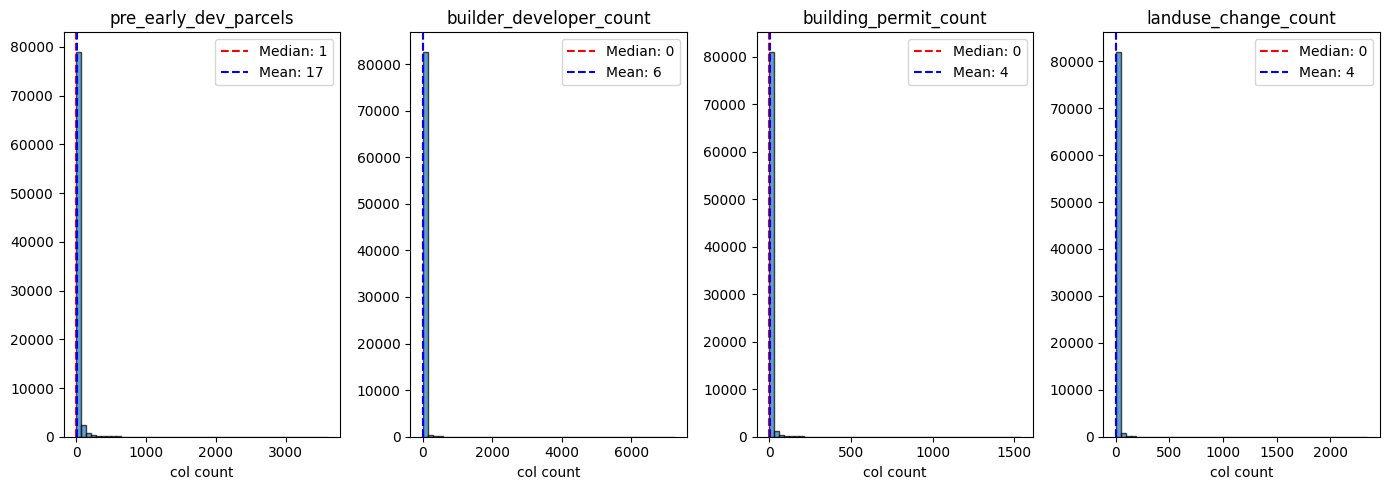

In [29]:
# Examine distribution of distance features
growth_cols = [
    'pre_early_dev_parcels',
    'builder_developer_count',
    'building_permit_count',
    'landuse_change_count'
]

# Summary stats
print("Summary stats for growth indicators:")
print(tract_df[growth_cols].describe().round(1).to_string())
print("="*80)

# Percentiles for non-NA values
print("Percentiles for distance features:")
for col in growth_cols:
    for p in [0.50, 0.75, 0.90, 0.95, 0.99]:
        print(f"  {col} P{int(p*100):02d}: {tract_df[col].quantile(p):.1f}")
    print()

# Distributions
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
for ax, col in zip(axes, growth_cols):
    data = tract_df[col].dropna()
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.0f}')
    ax.axvline(data.mean(), color='blue', linestyle='--', label=f'Mean: {data.mean():.0f}')
    ax.set_title(col)
    ax.set_xlabel('col count')
    ax.legend()
plt.tight_layout()

In [49]:
# Cap these columns at the 90th percentile to reduce skew and outlier impact
for col in growth_cols:
    cap_value = tract_df[col].quantile(0.90)
    tract_df[col] = tract_df[col].clip(upper=cap_value)
    print(f"{col} capped at {cap_value:.0f} (P90)")
    for p in [0.50, 0.75, 0.90, 0.95, 0.99]:
        print(f"{col} P{int(p*100):02d}: {tract_df[col].quantile(p):.1f}")
    print()

pre_early_dev_parcels capped at 39 (P90)
pre_early_dev_parcels P50: 1.0
pre_early_dev_parcels P75: 10.0
pre_early_dev_parcels P90: 39.0
pre_early_dev_parcels P95: 39.0
pre_early_dev_parcels P99: 39.0

builder_developer_count capped at 9 (P90)
builder_developer_count P50: 0.0
builder_developer_count P75: 2.0
builder_developer_count P90: 9.0
builder_developer_count P95: 9.0
builder_developer_count P99: 9.0

building_permit_count capped at 7 (P90)
building_permit_count P50: 0.0
building_permit_count P75: 1.0
building_permit_count P90: 7.0
building_permit_count P95: 7.0
building_permit_count P99: 7.0

landuse_change_count capped at 8 (P90)
landuse_change_count P50: 0.0
landuse_change_count P75: 2.0
landuse_change_count P90: 8.0
landuse_change_count P95: 8.0
landuse_change_count P99: 8.0



In [50]:
# Examine distribution of competitive landscape variable
print("Competitive landscape distribution:")
print(tract_df['provider_competitive_landscape'].value_counts(dropna=False).to_string())

Competitive landscape distribution:
provider_competitive_landscape
fiber_duopoly         29631
fiber_competitive     21948
fiber_saturated       15966
fiber_entry           13162
cable_but_no_fiber     2315
greenfield              216
no_providers             75


In [51]:
# Drop columns not useful for clustering
cols_to_drop = [
    'tract_geoid', 
    'estimated_fcc_units', 
    'provider_competitive_landscape',
    'pre_early_dev_parcels_bin',
    'landuse_change_count_bin',
    'builder_developer_count_bin',
    'building_permit_count_bin',
    'cable_future_gap' # NOTE: removing this because it is a redundant column with skewed distribution
    ]
df_clustering = tract_df.drop(columns=cols_to_drop)

# One-hot encode the ordinal feature
#df_clustering = pd.get_dummies(
#    df_clustering,
#    columns=['provider_competitive_landscape_ord'],
#    prefix='landscape',
#    dtype=int
#)

# Store feature column list for downstream use
feature_cols = df_clustering.columns.tolist()

# StandardScale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering)

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Final feature matrix shape: {X_scaled.shape}")

Features (13): ['pop_ch_avg', 'pop_pctch_avg', 'estimated_census_housing_units', 'pre_early_dev_parcels', 'builder_developer_count', 'landuse_change_count', 'building_permit_count', 'median_dist_nearest_hotspot', 'median_dist_nearest_fiber_m', 'cable_penetration', 'fiber_opportunity_gap', 'fiber_speed_top_tier', 'provider_competitive_landscape_ord']
Final feature matrix shape: (83313, 13)


k=2: inertia=939724, silhouette=0.2297
k=3: inertia=852471, silhouette=0.1173
k=4: inertia=778761, silhouette=0.1223
k=5: inertia=724061, silhouette=0.1289
k=6: inertia=687887, silhouette=0.1367
k=7: inertia=660079, silhouette=0.1376
k=8: inertia=637384, silhouette=0.1165


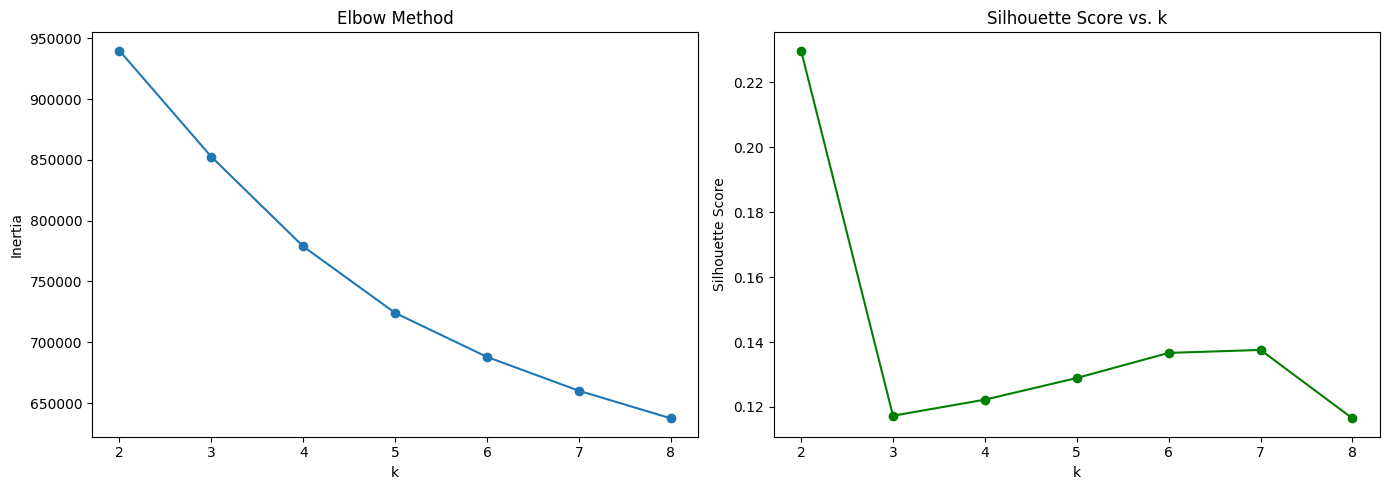

In [52]:
# Elbow method + Silhouette scores to determine optimal k
K_range = range(2,9)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"k={k}: inertia={km.inertia_:.0f}, silhouette={sil_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, sil_scores, marker='o', color='green')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs. k')
plt.tight_layout()

#### Running K-means with k = 6, 7, 8 one by one and examining:
1. Tract counts for each label
2. Silhouette score for each cluster
3. Mean/median values across features for each cluster
4. z-score distribution across clusters 

In [53]:
# Fit final k-means
k_optimal = 6  # adjust based on elbow/silhouette above
km_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)

print(f"Cluster distribution:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

Cluster distribution:
0    24227
1    10119
2     8456
3     4348
4    23833
5    12330
Name: count, dtype: int64


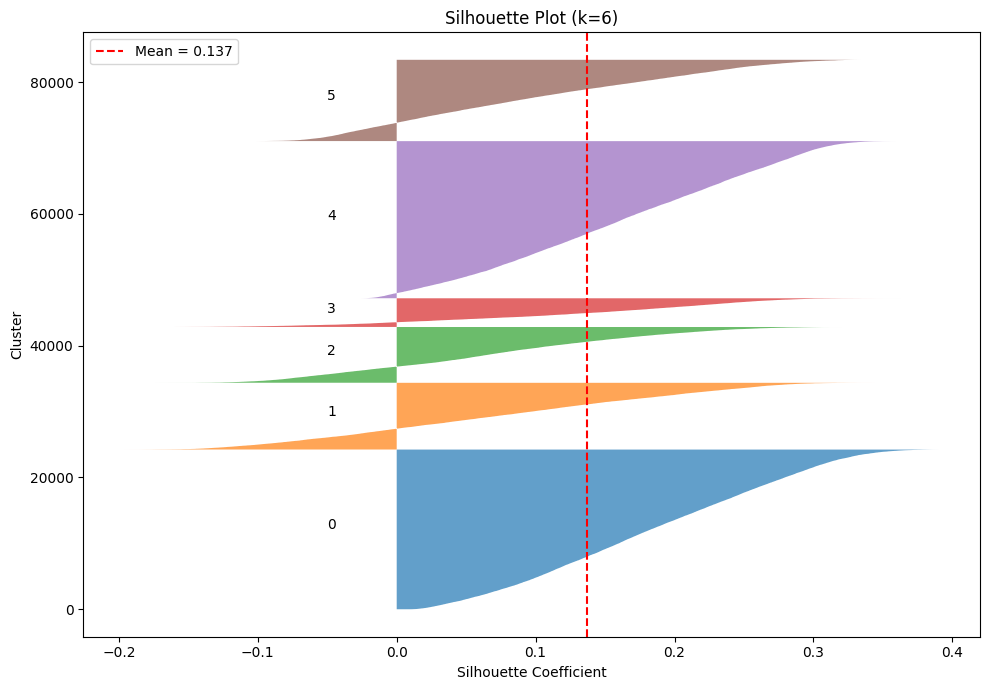

In [54]:
# Silhouette plot for chosen k
fig, ax = plt.subplots(figsize=(10, 7))
sil_values = silhouette_samples(X_scaled, cluster_labels)
y_lower = 10

for i in range(k_optimal):
    cluster_sil = np.sort(sil_values[cluster_labels == i])
    size_i = cluster_sil.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

mean_sil = silhouette_score(X_scaled, cluster_labels)
ax.axvline(mean_sil, color='red', linestyle='--', label=f'Mean = {mean_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot (k={k_optimal})')
ax.legend()
plt.tight_layout()

In [55]:
# Median of each feature by cluster 
# Add cluster labels to original dataframe for analysis
df_clustering['cluster'] = cluster_labels
cluster_medians = df_clustering.groupby('cluster')[feature_cols].median()

# Display with formatting
with pd.option_context('display.max_columns', None, 'display.width', None):
    print(cluster_medians.T.round(3).to_string())

cluster                                    0         1          2          3          4          5
pop_ch_avg                          1511.000  2842.000     47.000     21.000    464.000  14750.500
pop_pctch_avg                          0.480     1.520      0.260      0.180      0.160      1.280
estimated_census_housing_units      1540.000  2223.000   1699.000   1569.000   1539.000   1919.000
pre_early_dev_parcels                  0.000    35.000     26.000      6.000      0.000      0.000
builder_developer_count                0.000     9.000      1.000      0.000      0.000      0.000
landuse_change_count                   0.000     1.000      8.000      1.000      0.000      0.000
building_permit_count                  0.000     7.000      0.000      0.000      0.000      0.000
median_dist_nearest_hotspot         8057.147  1359.896  30169.037  30169.037  10198.945   4607.060
median_dist_nearest_fiber_m          356.944   818.090   2148.871  19742.781    495.470    242.588
cable_pene

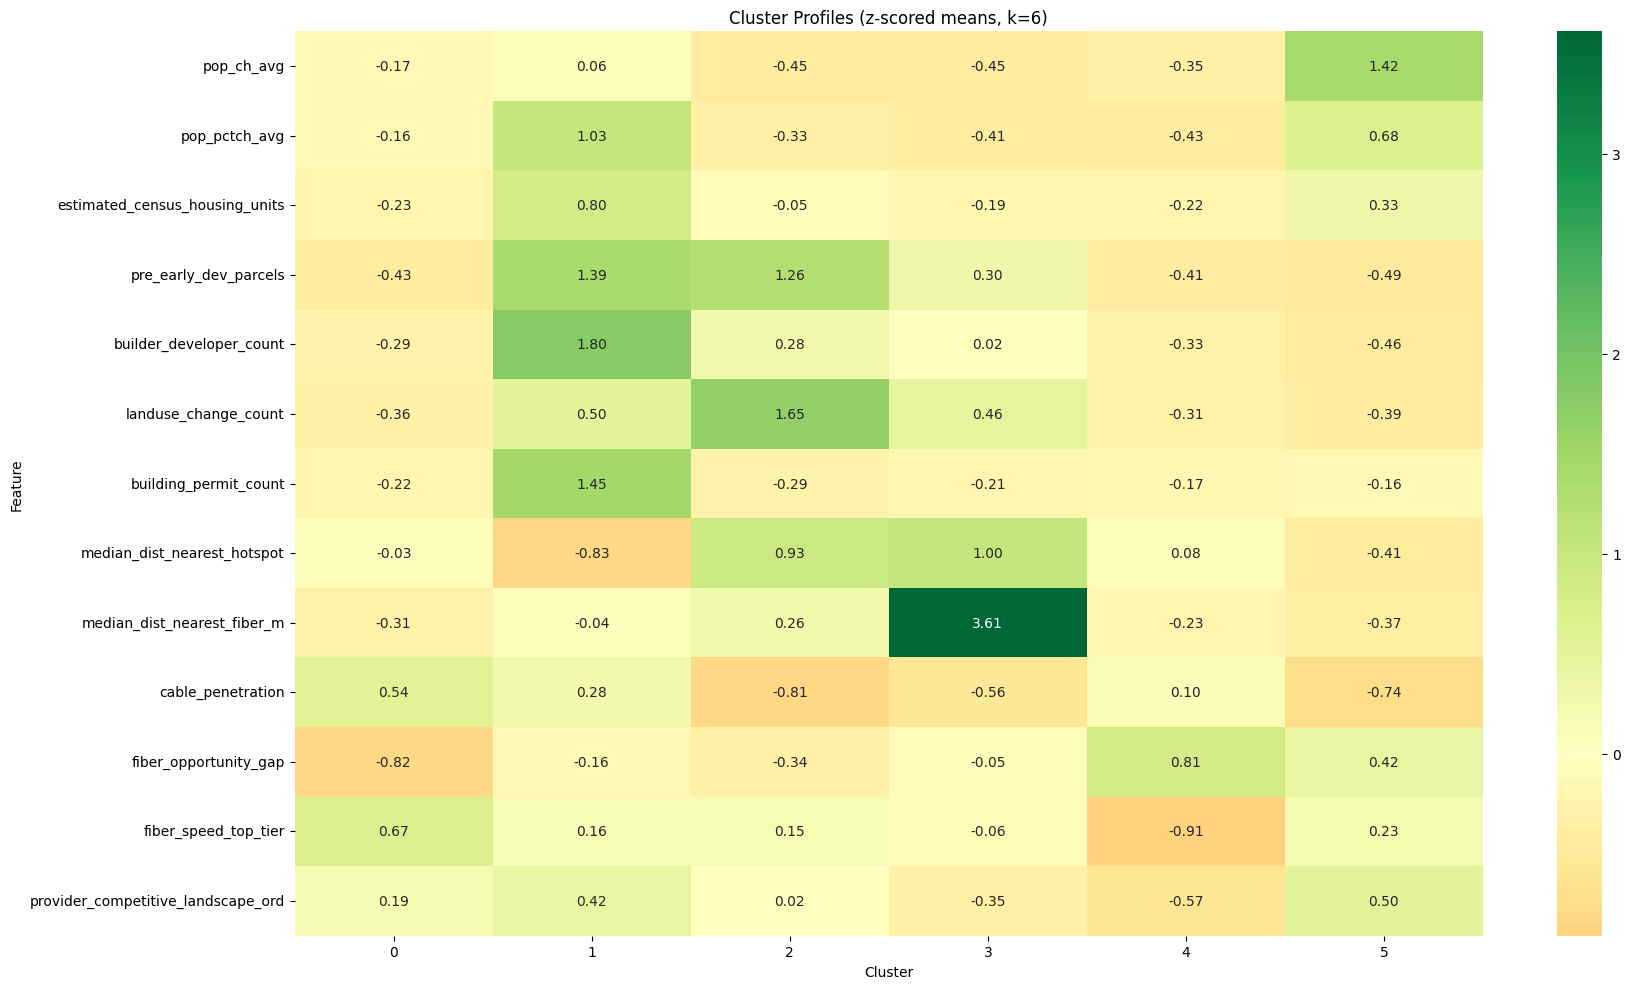

In [56]:
# Cluster profiles: z-scored means per cluster
df_clustering['cluster'] = cluster_labels

cluster_profiles = df_clustering.groupby('cluster')[feature_cols].mean()
cluster_profiles_z = (cluster_profiles - df_clustering[feature_cols].mean()) / df_clustering[feature_cols].std()

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(cluster_profiles_z.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title(f'Cluster Profiles (z-scored means, k={k_optimal})')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()

#### k=7

In [57]:
# Fit final k-means
k_optimal = 7  # adjust based on elbow/silhouette above
km_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)

print(f"Cluster distribution:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

Cluster distribution:
0     4246
1    22180
2     7501
3     7906
4    22777
5    11275
6     7428
Name: count, dtype: int64


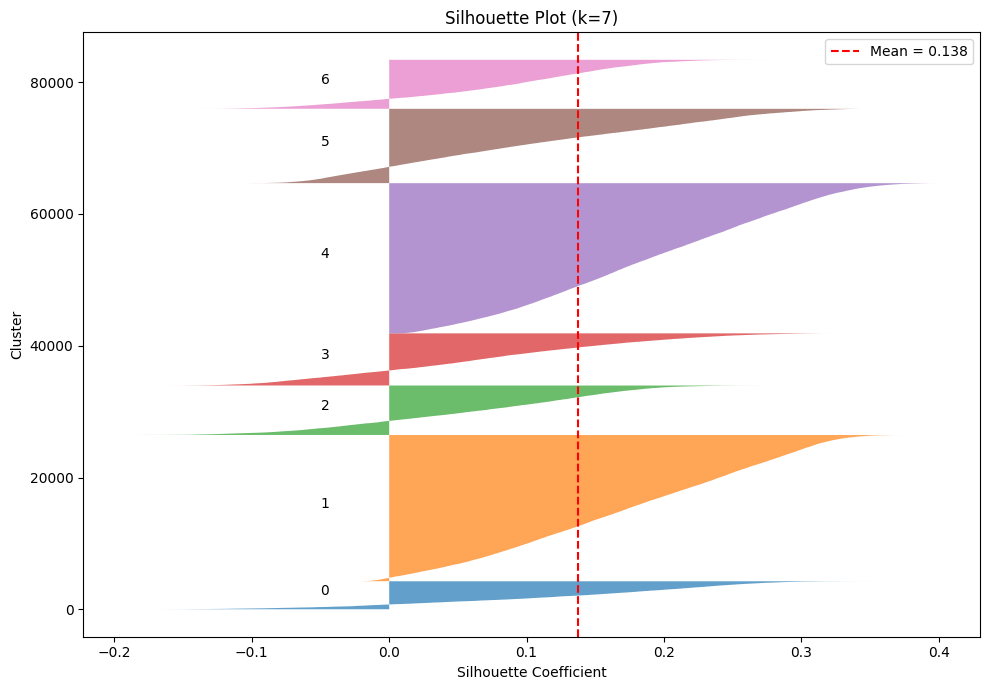

In [58]:
# Silhouette plot for chosen k
fig, ax = plt.subplots(figsize=(10, 7))
sil_values = silhouette_samples(X_scaled, cluster_labels)
y_lower = 10

for i in range(k_optimal):
    cluster_sil = np.sort(sil_values[cluster_labels == i])
    size_i = cluster_sil.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

mean_sil = silhouette_score(X_scaled, cluster_labels)
ax.axvline(mean_sil, color='red', linestyle='--', label=f'Mean = {mean_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot (k={k_optimal})')
ax.legend()
plt.tight_layout()

In [59]:
# Median of each feature by cluster 
df_clustering['cluster'] = cluster_labels
cluster_medians = df_clustering.groupby('cluster')[feature_cols].median()

# Display with formatting
with pd.option_context('display.max_columns', None, 'display.width', None):
    print(cluster_medians.T.round(3).to_string())

cluster                                     0          1         2          3         4          5         6
pop_ch_avg                             20.000    438.500  2631.000     40.000  1443.000  15526.000  2592.000
pop_pctch_avg                           0.170      0.150     1.620      0.240     0.470      1.270     0.860
estimated_census_housing_units       1569.500   1532.000  2334.000   1683.500  1538.000   1912.000  1800.000
pre_early_dev_parcels                   5.000      0.000    39.000     26.000     0.000      0.000     4.000
builder_developer_count                 0.000      0.000     9.000      1.000     0.000      0.000     1.000
landuse_change_count                    1.000      0.000     2.000      8.000     0.000      0.000     0.000
building_permit_count                   0.000      0.000     4.000      0.000     0.000      0.000     7.000
median_dist_nearest_hotspot         30169.037  10758.856  1218.700  30169.037  8467.050   4923.671  3332.689
median_dist_nearest

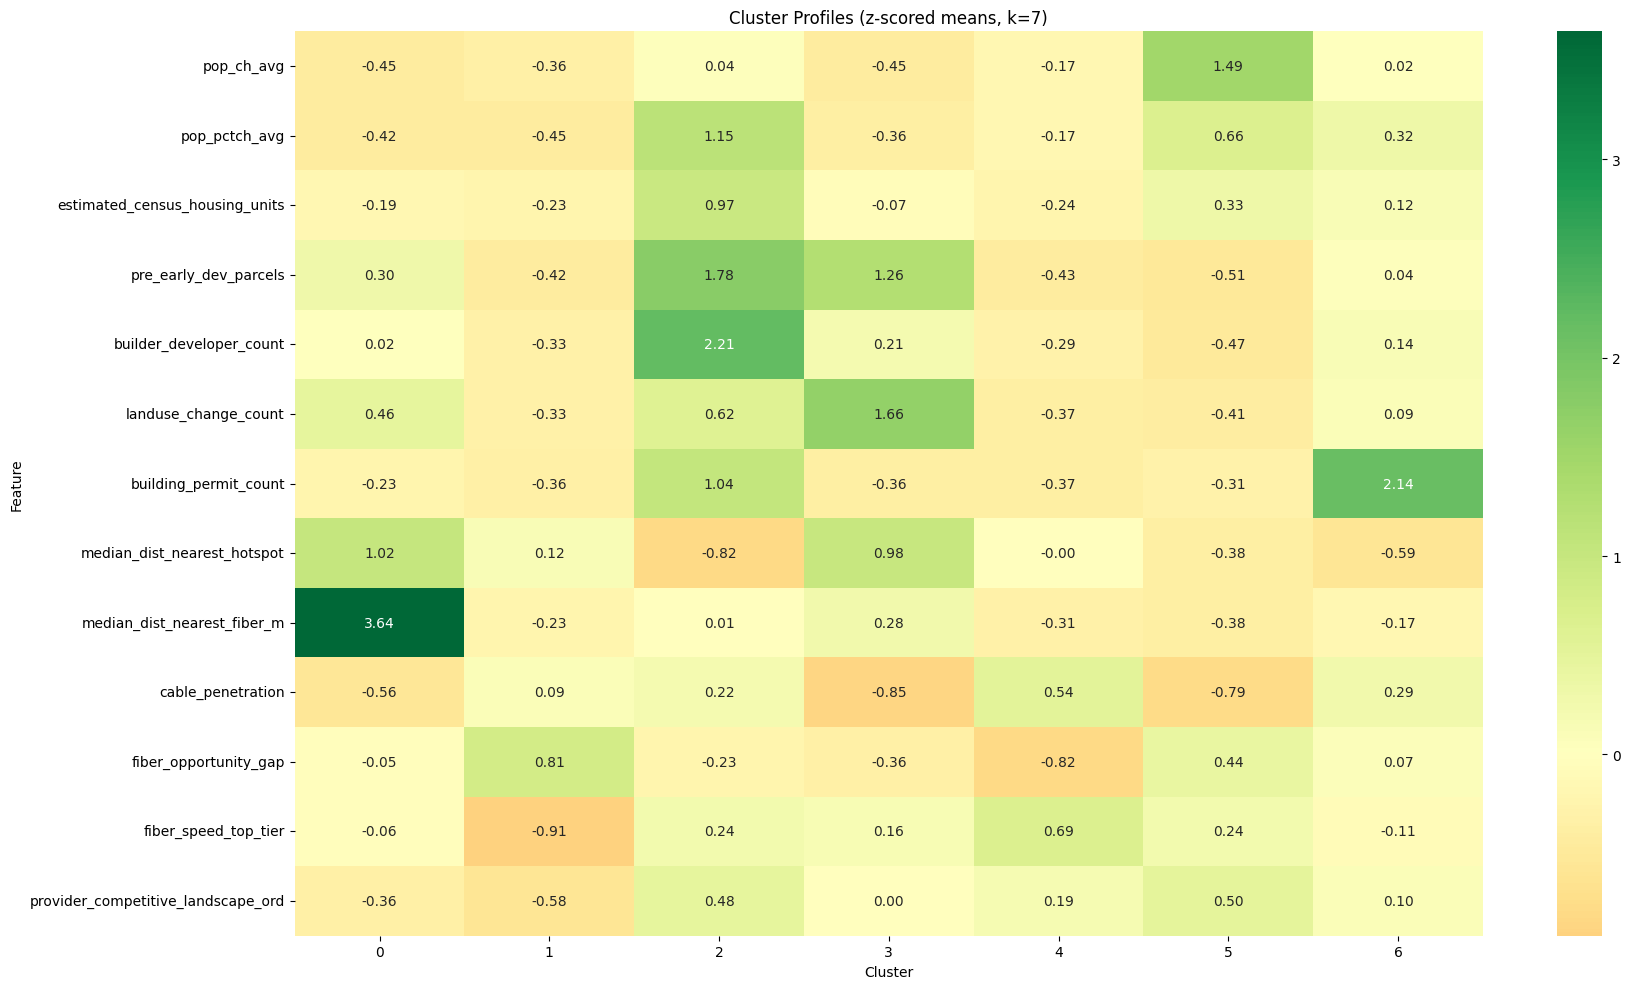

In [60]:
# Cluster profiles: z-scored means per cluster
df_clustering['cluster'] = cluster_labels

cluster_profiles = df_clustering.groupby('cluster')[feature_cols].mean()
cluster_profiles_z = (cluster_profiles - df_clustering[feature_cols].mean()) / df_clustering[feature_cols].std()

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(cluster_profiles_z.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title(f'Cluster Profiles (z-scored means, k={k_optimal})')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()

##### k=8


In [61]:
# Fit final k-means
k_optimal = 8  # adjust based on elbow/silhouette above
km_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)

print(f"Cluster distribution:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

Cluster distribution:
0    15356
1     6322
2     7381
3    16753
4    10480
5     4115
6    13708
7     9198
Name: count, dtype: int64


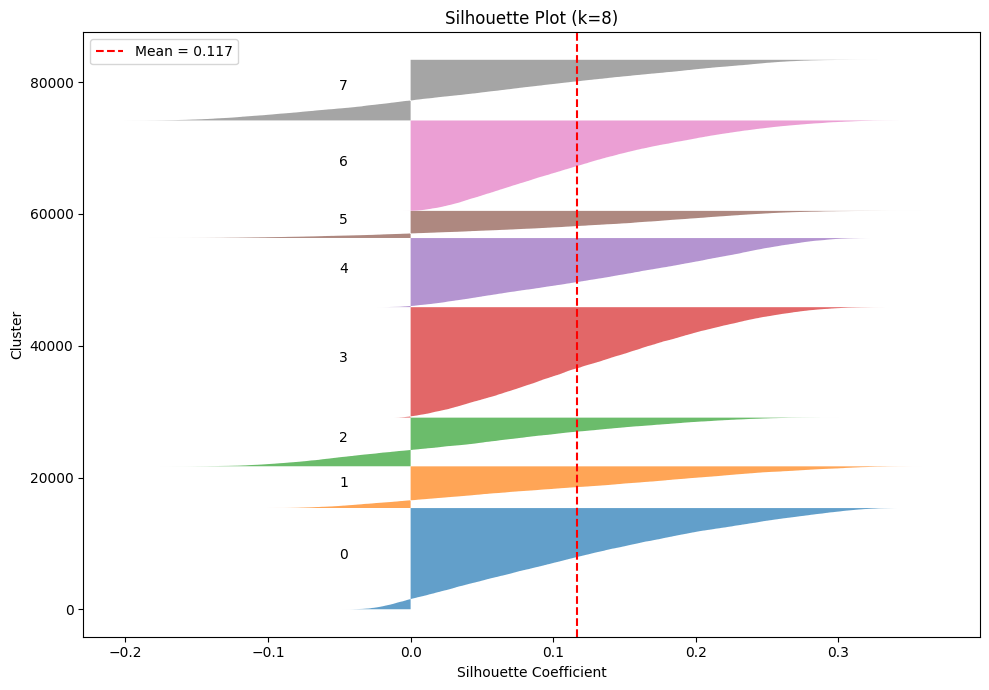

In [62]:
# Silhouette plot for chosen k
fig, ax = plt.subplots(figsize=(10, 7))
sil_values = silhouette_samples(X_scaled, cluster_labels)
y_lower = 10

for i in range(k_optimal):
    cluster_sil = np.sort(sil_values[cluster_labels == i])
    size_i = cluster_sil.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

mean_sil = silhouette_score(X_scaled, cluster_labels)
ax.axvline(mean_sil, color='red', linestyle='--', label=f'Mean = {mean_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot (k={k_optimal})')
ax.legend()
plt.tight_layout()

In [63]:
# Median of each feature by cluster 
df_clustering['cluster'] = cluster_labels
cluster_medians = df_clustering.groupby('cluster')[feature_cols].median()

# Display with formatting
with pd.option_context('display.max_columns', None, 'display.width', None):
    print(cluster_medians.T.round(3).to_string())

cluster                                     0          1          2         3          4          5         6         7
pop_ch_avg                            278.000  22790.000     60.000  3605.000     79.000     21.000  2182.000  2891.000
pop_pctch_avg                           0.150      1.360      0.320     0.810      0.110      0.180     0.410     1.580
estimated_census_housing_units       1423.000   1808.000   1729.000  1512.000   1558.000   1578.000  1949.000  2254.000
pre_early_dev_parcels                   0.000      0.000     30.000     0.000      0.000      6.000     0.000    39.000
builder_developer_count                 0.000      0.000      1.000     0.000      0.000      0.000     0.000     9.000
landuse_change_count                    0.000      0.000      8.000     0.000      0.000      1.000     0.000     1.000
building_permit_count                   0.000      0.000      0.000     0.000      0.000      0.000     0.000     7.000
median_dist_nearest_hotspot         1373

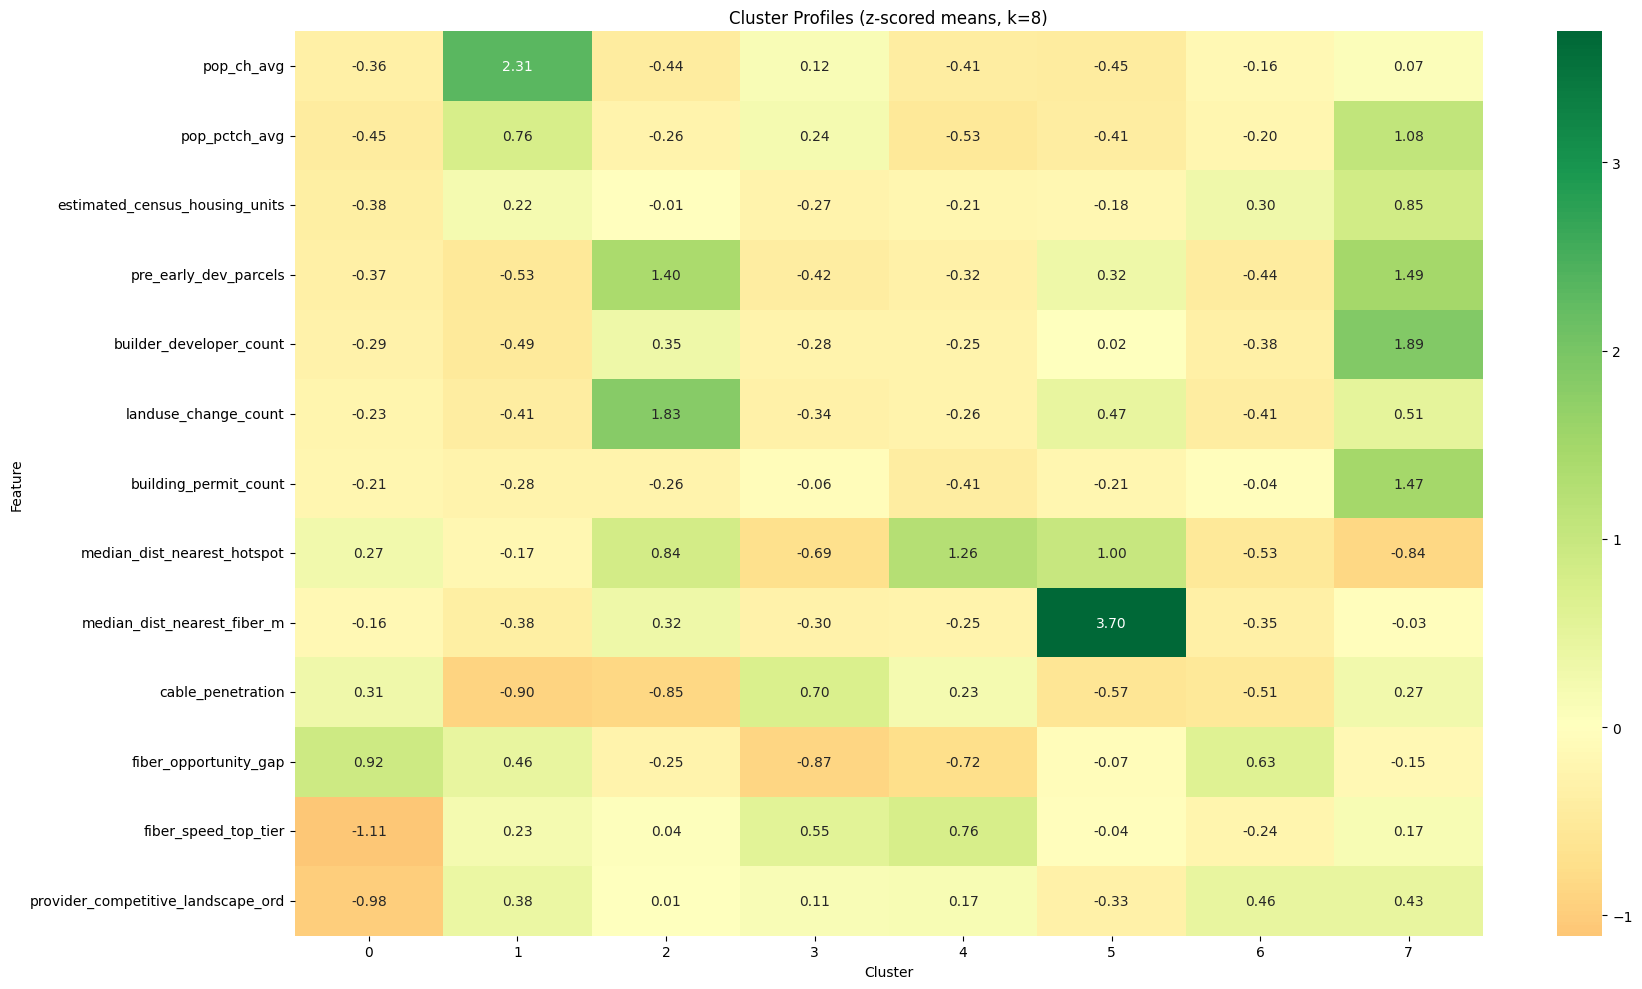

In [64]:
# Cluster profiles: z-scored means per cluster
df_clustering['cluster'] = cluster_labels

cluster_profiles = df_clustering.groupby('cluster')[feature_cols].mean()
cluster_profiles_z = (cluster_profiles - df_clustering[feature_cols].mean()) / df_clustering[feature_cols].std()

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(cluster_profiles_z.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title(f'Cluster Profiles (z-scored means, k={k_optimal})')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()

In [65]:
df_clustering.info()

<class 'pandas.DataFrame'>
RangeIndex: 83313 entries, 0 to 83312
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   pop_ch_avg                          83313 non-null  float64
 1   pop_pctch_avg                       83313 non-null  float64
 2   estimated_census_housing_units      83313 non-null  int64  
 3   pre_early_dev_parcels               83313 non-null  float64
 4   builder_developer_count             83313 non-null  float64
 5   landuse_change_count                83313 non-null  float64
 6   building_permit_count               83313 non-null  float64
 7   median_dist_nearest_hotspot         83313 non-null  float64
 8   median_dist_nearest_fiber_m         83313 non-null  float64
 9   cable_penetration                   83313 non-null  float64
 10  fiber_opportunity_gap               83313 non-null  float64
 11  fiber_speed_top_tier                83313 non-null  

In [67]:
# Cell 10 - Upload tract_df_final to BQ (teu_analytics dataset)
# TODO: Update table_id = f"{GCS_PROJECT_ID}.teu_analytics.kmeans_clusters_tract"
tract_df['cluster'] = df_clustering['cluster']
assert tract_df.index.equals(df_clustering.index), "Indexes don't match"

client = bigquery.Client(project=GCS_PROJECT_ID)
table_id = f"{GCS_PROJECT_ID}.teu_analytics.results_clustering_k8_tract"

job_config = bigquery.LoadJobConfig(
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
)

job = client.load_table_from_dataframe(tract_df, table_id, job_config=job_config)
job.result()

print(f"Uploaded {job.output_rows} rows to {table_id}")

/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Uploaded 83313 rows to clgx-gis-app-dev-06e3.teu_analytics.results_clustering_k8_tract


##### Cluster Interpretation:
| Cluster | Size   | Likely Tier      | Reasoning                                          |
|---------|--------|------------------|-----------------------------------------------------|
| 7       | 9,198  | Tier 1 — best    | Growth + housing + fiber gap, near hotspots          |
| 0       | 15,356 | Tier 1 — best    | Strong fiber gap in cable-only mature markets        |
| 2       | 7,381  | Tier 2           | Active development with moderate fiber gap           |
| 1       | 6,322  | Tier 2           | Pop growth without much physical change, moderate gap|
| 6       | 13,708 | Tier 3 — middle  | Average across the board                             |
| 3       | 16,753 | Tier 3 — middle  | Already well-served despite some growth              |
| 5       | 4,115  | Tier 4 — hard    | Very rural, hard to deploy                           |
| 4       | 10,480 | Tier 4 — avoid   | Saturated rural, no growth    